In [55]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import math
import h5py

# 从 tensorflow 导入 Keras 模块 (遵循实验指导书推荐的方式)
from tensorflow.keras.models import Sequential, Model # 导入 Sequential 和 Functional Model
from tensorflow.keras.layers import InputLayer, Input, Reshape, MaxPooling2D, Conv2D, Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K 


In [56]:
# 导入用于加载MNIST数据的包
from keras.datasets import mnist

(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [57]:
# 图像的每个维度中的像素数。
img_size = 28

# 图像存储在一维矩阵中的总长度
img_size_flat = 28 * 28

# 用来重塑图像的高度和宽度的元组。
img_shape = (28,28)

# 用来重塑图像的高度，宽度和深度的元组。
# 这用于在Keras重塑。
img_shape_full = (28,28,1)

# 类别数量
num_classes = 10

# 图像的通道数
num_channels = 1

# 打印显示变量
print(img_size)
print(img_size_flat)
print(img_shape)
print(img_shape_full)
print(num_classes)
print(num_channels)

28
784
(28, 28)
(28, 28, 1)
10
1


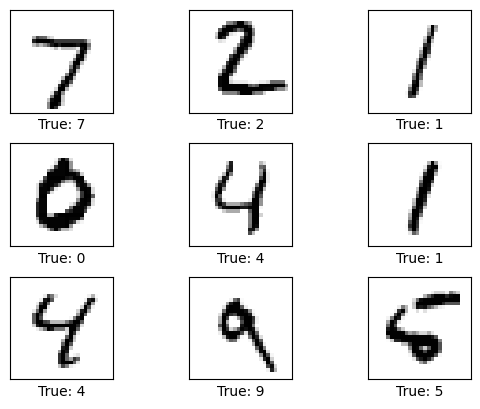

In [58]:
def plot_images(images, cls_true, cls_pred=None):
    """
    绘制9张图像，并显示它们的真实类别和可选的预测类别。
    参数:
    images: 图像数组 (必须包含9张图像)。
    cls_true: 图像真实的类别标签数组。
    cls_pred: 图像预测的类别标签数组 (可选)。
    """
    # 确保输入的图像和标签长度都为9
    assert len(images) == len(cls_true) == 9
    
    # [cite_start]创建3x3子图[cite: 6].
    fig, axes = plt.subplots(3, 3)
    fig.subplots_adjust(hspace=0.3, wspace=0.3)

    for i, ax in enumerate(axes.flat):
        # [cite_start]画图[cite: 7].
        # 将一维图像数组重塑为 (img_size, img_size) 并以二值颜色模式显示
        ax.imshow(images[i].reshape(img_shape), cmap='binary')

        # [cite_start]显示真正的类别和/或预测的类别[cite: 8].
        if cls_pred is None:
            xlabel = "True: {0}".format(cls_true[i])
        else:
            xlabel = "True: {0}, Pred: {1}".format(cls_true[i], cls_pred[i])

        # 将类别作为x轴的标签
        ax.set_xlabel(xlabel)
        
        # [cite_start]去除图中的刻度线[cite: 9].
        ax.set_xticks([])
        ax.set_yticks([])
    
    plt.show()


# ---------------------------------------------
# 检测函数：打印测试集前9张图片来检测该函数是否正确
# ---------------------------------------------

# 获取测试集前9张图像
images = x_test[0:9]

# 获取这些图像的真实类别
cls_true = y_test[0:9]

# 调用辅助函数绘制图像
plot_images(images=images, cls_true=cls_true)

In [59]:
def plot_example_errors(cls_pred, correct):
    """
    绘制测试集中分类错误的图像样本。

    参数:
    cls_pred: 测试集所有图像的预测类别。
    correct: 布尔数组，表示每个图像的预测是否等于真实类别 。
    """
    
    # 布尔数组中未正确分类的图像 
    incorrect = (correct == False)
    
    # 从测试集中获取未正确分类的图片XQ
    images = x_test[incorrect]
    
    # 获取这些图像的预测列表
    cls_pred = cls_pred[incorrect]
    
    # 获取这些图像的正确类别
    cls_true = y_test[incorrect]
    
    # 画出前9张图像
    plot_images(images=images[0:9],
                cls_true=cls_true[0:9],
                cls_pred=cls_pred[0:9])

In [60]:
# 开始构建Keras 序列模型。
model = Sequential()

# 添加一个输入层。输入形状 input_shape 必须是包含图像像素总数 img_size_flat 的元组。
model.add(InputLayer(input_shape=(img_size_flat,))) # 

# 输入是一个包含784个元素的扁平数组，
# 卷积层期望图像形状是 (28, 28, 1)，因此需要重塑。
model.add(Reshape(img_shape_full)) # 

# 具有ReLU激活和最大池化的第一个卷积层。
model.add(Conv2D(kernel_size=5, strides=1, filters=16, padding='same', 
                 activation='relu', name='layer_conv1')) # 
model.add(MaxPooling2D(pool_size=2, strides=2)) # 

# 具有ReLU激活和最大池化的第二个卷积层
model.add(Conv2D(kernel_size=5, strides=1, filters=36, padding='same', 
                 activation='relu', name='layer_conv2')) # [cite: 12, 13]
model.add(MaxPooling2D(pool_size=2, strides=2)) # [cite: 13]

# 将卷积层的输出展平为一维，输入到全连接/密集层。
model.add(Flatten()) # [cite: 13]

# 具有ReLU激活的第一个全连接/密集层。
model.add(Dense(128, activation='relu')) # [cite: 13]

# 最后一个全连接/密集层，具有 softmax 激活功能，用于分类。
model.add(Dense(num_classes, activation='softmax')) # [cite: 13]

# 通过 model.summary() 查看模型结构和参数数量
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape_4 (Reshape)         (None, 28, 28, 1)         0         
                                                                 
 layer_conv1 (Conv2D)        (None, 28, 28, 16)        416       
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 14, 14, 16)       0         
 2D)                                                             
                                                                 
 layer_conv2 (Conv2D)        (None, 14, 14, 36)        14436     
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 7, 7, 36)         0         
 2D)                                                             
                                                                 
 flatten_4 (Flatten)         (None, 1764)             

In [61]:
from tensorflow.keras.metrics import Precision, Recall

custom_metrics = [
    'accuracy',       # 默认的准确率 (CategoricalAccuracy 的简写)
    Precision(),      # 精确率 (使用类的形式)
    Recall()          # 召回率 (使用类的形式)
]

# 实例化一个 Adam 优化器，并设置学习率为 1e-3 (即 0.001)
optimizer = Adam(learning_rate=1e-3)

# 编译模型，设置优化器、损失函数和性能指标
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=custom_metrics)

In [62]:
import tensorflow as tf
# 注意：img_size_flat 和 num_classes 必须已由 1.3 节代码定义

print("--- 开始数据预处理 ---")

# 1. 归一化：将像素值从 0-255 转换为 0.0-1.0
# 并且将其转换为浮点数类型
x_train_normalized = x_train.astype('float32') / 255.0
# x_test_normalized = x_test.astype('float32') / 255.0 # 测试集预处理留待后面评估使用

# 2. 扁平化：将 (28, 28) 形状的图像展平为 (784,)，以匹配模型的 InputLayer
# 形状：(样本数, 28, 28) -> (样本数, 784)
x_train_flat = x_train_normalized.reshape(x_train_normalized.shape[0], img_size_flat)

# 3. 标签 One-Hot 编码：将整数标签 (0-9) 转换为 One-Hot 向量
y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)

# 验证 X_train 的形状和数据类型
print("x_train_flat 最终验证:")
print(f"  形状 (Shape): {x_train_flat.shape}")
print(f"  数据类型 (dtype): {x_train_flat.dtype}")

# 验证 X_test 的形状和数据类型
print("y_train_one_hot 最终验证:")
print(f"  形状 (Shape): {y_train_one_hot.shape}")
print(f"  数据类型 (dtype): {y_train_one_hot.dtype}")

print("--- 数据预处理完成 ---")

# 拟合模型，使用处理后的训练集进行训练
print("--- 开始模型训练 ---")
model.fit(x=x_train_flat, 
          y=y_train_one_hot, 
          epochs=1, 
          batch_size=128)
          
print("--- 模型训练完成 ---")

--- 开始数据预处理 ---
x_train_flat 最终验证:
  形状 (Shape): (60000, 784)
  数据类型 (dtype): float32
y_train_one_hot 最终验证:
  形状 (Shape): (60000, 10)
  数据类型 (dtype): float32
--- 数据预处理完成 ---
--- 开始模型训练 ---
469/469 [==============================] - 36s 74ms/step - loss: 0.2084 - accuracy: 0.9393 - precision_3: 0.9656 - recall_3: 0.9128
--- 模型训练完成 ---


In [63]:
# 评估模型在测试集上的性能
x_test_normalized = x_test.astype('float32') / 255.0
x_test_flat = x_test_normalized.reshape(x_test_normalized.shape[0], img_size_flat)
y_test_one_hot = tf.keras.utils.to_categorical(y_test, num_classes=num_classes)
# x_test_flat: 已归一化和扁平化的测试图像
# y_test_one_hot: 已 One-Hot 编码的测试标签
result = model.evaluate(x=x_test_flat,
                        y=y_test_one_hot,
                        # 确保批次大小与训练时保持一致或默认（此处省略 batch_size，Keras会使用默认值）
                        verbose=1) # verbose=1 显示进度条

print("\n--- 性能指标 ---")

# 使用 zip 函数和循环来访问键值对 (符合参考代码中的提示)
# model.metrics_names 包含损失函数和所有度量指标的名称，例如 ['loss', 'accuracy', ...]
for name, value in zip(model.metrics_names, result):
    # 打印结果
    print(f"{name} {value}")

313/313 [==============================] - 3s 9ms/step - loss: 0.0829 - accuracy: 0.9704 - precision_3: 0.9743 - recall_3: 0.9677

--- 性能指标 ---
loss 0.08291394263505936
accuracy 0.9703999757766724
precision_3 0.97432541847229
recall_3 0.9677000045776367


--- 开始预测测试集前9张图片 ---
1/1 [==============================] - 0s 147ms/step
--- 预测结果绘图 ---


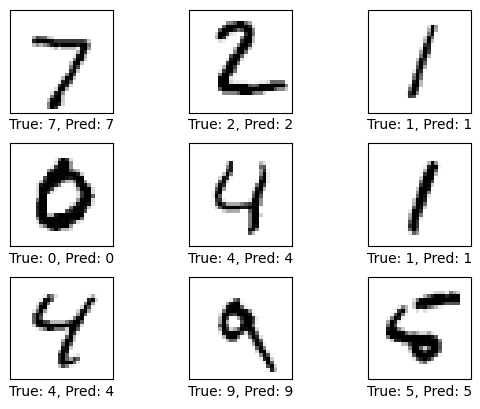

In [64]:
print("--- 开始预测测试集前9张图片 ---")

# 1. 获取测试集前9张图像（已归一化和扁平化）
x_test_9 = x_test_flat[0:9]

# 2. 获取测试集前9张图像的真实类别 (整数形式 y_test)
# 注意：y_test 是整数标签，不需要再转换
cls_true = y_test[0:9] 

# 3. 使用模型进行预测 (返回 One-Hot 编码的概率)
y_pred = model.predict(x=x_test_9)

# 4. 将 One-Hot 预测结果转换为整数类别
# np.argmax 返回每行（即每个样本）最大概率值所在的索引，即预测的类别
cls_pred = np.argmax(y_pred, axis=1)

# 5. 调用辅助函数绘制图像并显示预测结果
# plot_images 需要原始的图像数据 (28x28 形状)
images_to_plot = x_test[0:9] 

print("--- 预测结果绘图 ---")
# 注意：plot_images 函数断言输入长度必须为 9
plot_images(images=images_to_plot,
            cls_true=cls_true,
            cls_pred=cls_pred)

--- 开始预测整个测试集 ---
313/313 [==============================] - 2s 6ms/step
--- 绘制前9张错分类的图像 ---


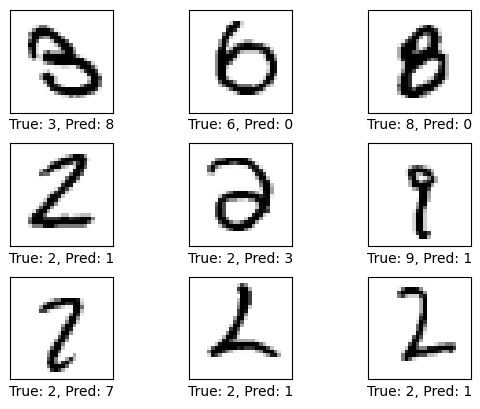

In [65]:
print("--- 开始预测整个测试集 ---")

# 1. 从测试集中得到所有图像的预测类 (返回 One-Hot 编码的概率)
# 使用已扁平化和归一化的测试集数据 x_test_flat
y_pred = model.predict(x=x_test_flat)

# 2. 将 One-Hot 预测结果转换为整数类别，赋值给 cls_pred
cls_pred = np.argmax(y_pred, axis=1)

# 3. 获取测试集的真实类别 (整数形式 y_test)
cls_true = y_test

# 4. 创建一个布尔数组，指示预测是否正确 (correct)
# correct 为 True 表示预测正确，False 表示预测错误
correct = (cls_pred == cls_true)

print("--- 绘制前9张错分类的图像 ---")
# 5. 调用 plot_example_errors 绘制前九张错分类的图像
# plot_example_errors 函数内部会筛选出 incorrect 的样本并绘图
plot_example_errors(cls_pred=cls_pred, correct=correct)

In [66]:
print("--- 开始构建 Keras 功能模型 (Functional Model) ---")

# 1. 创建一个输入层。输入形状 shape 必须是包含图像像素总数 img_size_flat 的元组。
inputs = Input(shape=(img_size_flat,))

# 用于构建神经网络的变量。
net = inputs

# 2. 重塑层：将一维输入 (784,) 重塑为 4 维 (样本数, 28, 28, 1)，以适应卷积层。
net = Reshape(img_shape_full)(net)

# 3. 具有 ReLU 激活和最大池化的第一个卷积层。
net = Conv2D(kernel_size=5, strides=1, filters=16, padding='same',
             activation='relu', name='layer_conv1')(net)
net = MaxPooling2D(pool_size=2, strides=2)(net)

# 4. 具有 ReLU 激活和最大池化的第二个卷积层。
net = Conv2D(kernel_size=5, strides=1, filters=36, padding='same',
             activation='relu', name='layer_conv2')(net)
net = MaxPooling2D(pool_size=2, strides=2)(net)

# 5. 展平层：将卷积层的输出展平为一维。
net = Flatten()(net)

# 6. 具有 ReLU 激活的第一个全连接/密集层。
net = Dense(128, activation='relu')(net)

# 7. 最后一个全连接/密集层，具有 softmax 激活功能，用于分类。
net = Dense(num_classes, activation='softmax')(net)

# 8. 神经网络输出
outputs = net

model2 = Model(inputs=inputs, outputs=outputs)

print("--- Functional Model 结构概览 ---")

# 2. 打印模型的结构概览
model2.summary()

print("--- 功能模型架构定义完成 ---")

--- 开始构建 Keras 功能模型 (Functional Model) ---
--- Functional Model 结构概览 ---
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 784)]             0         
                                                                 
 reshape_5 (Reshape)         (None, 28, 28, 1)         0         
                                                                 
 layer_conv1 (Conv2D)        (None, 28, 28, 16)        416       
                                                                 
 max_pooling2d_10 (MaxPoolin  (None, 14, 14, 16)       0         
 g2D)                                                            
                                                                 
 layer_conv2 (Conv2D)        (None, 14, 14, 36)        14436     
                                                                 
 max_pooling2d_11 (MaxPoolin  (None, 7, 7, 36)        

In [67]:
# 1. 创建新的模型实例，并赋值给 model2
# inputs 和 outputs 是在 3.1 节代码中定义的变量
model2 = Model(inputs=inputs, outputs=outputs)

# 创建一个包含多个指标的列表
custom_metrics = [
    'accuracy',       # 默认的准确率 (CategoricalAccuracy 的简写)
    Precision(),      # 精确率 (使用类的形式)
    Recall()          # 召回率 (使用类的形式)
]

# 2. 编译模型：优化器选择 'rmsprop'，损失函数和性能指标与 Sequential 模型保持一致
model2.compile(optimizer='rmsprop',
               loss='categorical_crossentropy',
               metrics=custom_metrics)

print("--- 功能模型 model2 编译完成 ---")

--- 功能模型 model2 编译完成 ---


In [68]:
print("--- 开始功能模型 model2 训练 ---")

# 拟合模型，使用处理后的训练集进行训练
# x_train_flat: 归一化和扁平化后的图像数据
# y_train_one_hot: One-Hot 编码的标签数据
model2.fit(x=x_train_flat, 
           y=y_train_one_hot, 
           epochs=1, 
           batch_size=128)
          
print("--- 功能模型 model2 训练完成 ---")

--- 开始功能模型 model2 训练 ---
469/469 [==============================] - 12s 23ms/step - loss: 0.1856 - accuracy: 0.9423 - precision_4: 0.9659 - recall_4: 0.9231
--- 功能模型 model2 训练完成 ---


In [69]:
import numpy as np

print("--- 开始功能模型 model2 评估 ---")

# 评估模型在测试集上的性能
# x_test_flat: 已归一化和扁平化的测试图像
# y_test_one_hot: 已 One-Hot 编码的测试标签
result = model2.evaluate(x=x_test_flat,
                         y=y_test_one_hot,
                         verbose=1) # verbose=1 显示进度条

print("\n--- model2 性能指标 ---")

# 1. 打印所有性能指标
# model2.metrics_names 包含损失函数和所有度量指标的名称，例如 ['loss', 'accuracy']
print("所有指标 (名称, 值):")
for name, value in zip(model2.metrics_names, result):
    print(f"{name}: {value}")

# 2. 打印准确率的结果
# 准确率通常是 result 列表中的第二个元素，因为第一个是 loss
# 可以通过 model2.metrics_names.index('accuracy') 找到准确率的位置
accuracy_index = model2.metrics_names.index('accuracy')
accuracy = result[accuracy_index]

print(f"\n准确率 (Accuracy): {accuracy}")

--- 开始功能模型 model2 评估 ---
313/313 [==============================] - 3s 9ms/step - loss: 0.0551 - accuracy: 0.9821 - precision_4: 0.9846 - recall_4: 0.9800

--- model2 性能指标 ---
所有指标 (名称, 值):
loss: 0.05505852773785591
accuracy: 0.9821000099182129
precision_4: 0.9846277236938477
recall_4: 0.9800000190734863

准确率 (Accuracy): 0.9821000099182129


--- 开始预测整个测试集 (model2) ---
313/313 [==============================] - 5s 15ms/step
--- 绘制 model2 的前9张错分类的图像 ---


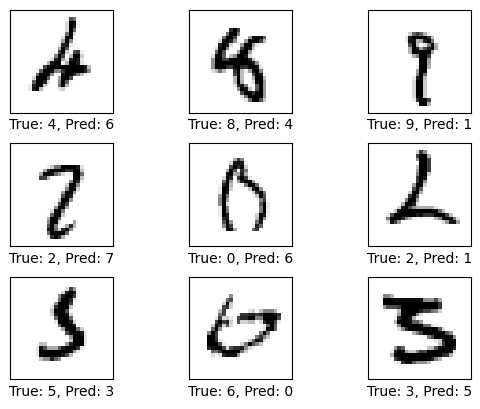

In [70]:
import numpy as np

print("--- 开始预测整个测试集 (model2) ---")

# 1. 使用 model2 对整个测试集进行预测 (返回 One-Hot 编码的概率)
# 使用已扁平化和归一化的测试集数据 x_test_flat
y_pred_model2 = model2.predict(x=x_test_flat)

# 2. 将 One-Hot 预测结果转换为整数类别，赋值给 cls_pred
cls_pred_model2 = np.argmax(y_pred_model2, axis=1)

# 3. 获取测试集的真实类别 (整数形式 y_test)
cls_true = y_test

# 4. 创建一个布尔数组，指示预测是否正确 (correct)
# correct 为 True 表示预测正确，False 表示预测错误
correct_model2 = (cls_pred_model2 == cls_true)

print("--- 绘制 model2 的前9张错分类的图像 ---")
# 5. 调用 plot_example_errors 绘制前九张错分类的图像
# 注意：plot_example_errors 函数内部会筛选出 incorrect 的样本并绘图
plot_example_errors(cls_pred=cls_pred_model2, correct=correct_model2)

In [71]:
import os

# 1. 设置模型的保存路径
# 推荐使用 .keras 格式，它包含了模型架构、权重和训练配置（优化器状态等）
path_model = 'functional_model.keras'

# 确保文件夹存在（如果路径包含目录）
folder = os.path.dirname(path_model)
if folder and not os.path.exists(folder):
     os.makedirs(folder)

# 2. 保存模型 model2
model2.save(path_model)

print(f"--- 模型 model2 已成功保存到: {path_model} ---")

--- 模型 model2 已成功保存到: functional_model.keras ---


In [72]:
# 导入所需的库
import gc

print("--- 开始删除模型 model2 ---")

# 使用 del 关键字删除 model2
del model2

# 强制进行垃圾回收，确保模型及其占用的内存被释放
gc.collect()

print("--- 模型 model2 已从内存中删除 ---")

--- 开始删除模型 model2 ---
--- 模型 model2 已从内存中删除 ---


In [73]:
# 确保 path_model 变量已经被定义 (例如：path_model = 'functional_model.keras')
# 如果您没有运行 4.1 节代码，请手动定义它：
path_model = 'functional_model.keras'

# 导入加载模型的函数 (使用标准路径，避免兼容性问题)
from tensorflow.keras.models import load_model 

print("--- 开始加载模型到 model3 ---")

# 从保存的路径加载模型，并赋值给 model3
# 加载的模型包含了模型的架构、权重、以及编译时的配置（优化器等）
model3 = load_model(path_model)

# 打印模型结构，确认加载成功
print("\n--- 加载模型 model3 结构概览 ---")
model3.summary()

--- 开始加载模型到 model3 ---

--- 加载模型 model3 结构概览 ---
Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 784)]             0         
                                                                 
 reshape_5 (Reshape)         (None, 28, 28, 1)         0         
                                                                 
 layer_conv1 (Conv2D)        (None, 28, 28, 16)        416       
                                                                 
 max_pooling2d_10 (MaxPoolin  (None, 14, 14, 16)       0         
 g2D)                                                            
                                                                 
 layer_conv2 (Conv2D)        (None, 14, 14, 36)        14436     
                                                                 
 max_pooling2d_11 (MaxPoolin  (None, 7, 7, 36)         0         
 g2D)     

--- 开始用加载的模型 model3 预测测试集前9张图片 ---
1/1 [==============================] - 0s 184ms/step
--- model3 预测结果绘图 ---


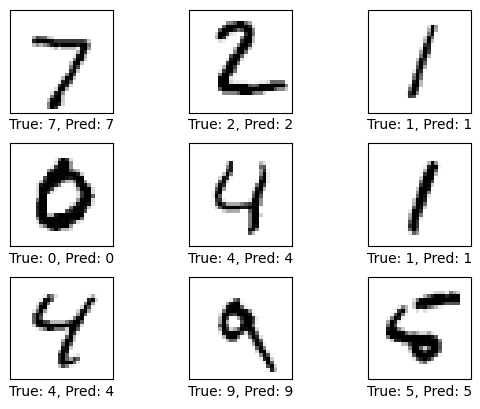

In [74]:
print("--- 开始用加载的模型 model3 预测测试集前9张图片 ---")

# 1. 获取测试集前9张图像（已归一化和扁平化）
# 注意：x_test_flat 是全局变量，包含了预处理后的数据
x_test_9 = x_test_flat[0:9]

# 2. 获取测试集前9张图像的真实类别 (整数形式 y_test)
cls_true = y_test[0:9] 

# 3. 使用 model3 进行预测
y_pred_model3 = model3.predict(x=x_test_9)

# 4. 将 One-Hot 预测结果转换为整数类别
cls_pred_model3 = np.argmax(y_pred_model3, axis=1)

# 5. 调用辅助函数绘制图像并显示预测结果
# plot_images 需要原始的图像数据 (28x28 形状)
images_to_plot = x_test[0:9] 

print("--- model3 预测结果绘图 ---")
# 注意：plot_images 函数断言输入长度必须为 9
plot_images(images=images_to_plot,
            cls_true=cls_true,
            cls_pred=cls_pred_model3)

In [77]:
def plot_conv_weights(weights, input_channel=0):
    """
    绘制卷积核权重。
    
    参数:
    weights: 卷积层的权重 (4维张量)。
    input_channel: 要可视化的输入通道索引 (默认为0)。
    """
    # 获取权重的最低值和最高值
    # 这用于校正图像的颜色强度，以便可以相互比较.
    w_min = np.min(weights)
    w_max = np.max(weights)
    
    # 卷积层中的卷积核数量
    # 权重形状是 [height, width, input_channels, output_channels (filters)]
    num_filters = weights.shape[3]
    
    # 要绘制的网格数.
    # 卷积核数量的平方根并向上取整.
    num_grids = math.ceil(math.sqrt(num_filters))
    
    # 创建带有网格子图的图像 (num_grids x num_grids).
    fig, axes = plt.subplots(num_grids, num_grids)
    
    # 绘制所有卷积核的权重
    for i, ax in enumerate(axes.flat):
        # 仅绘制有限的卷积核权重
        if i < num_filters:
            # 获取输入通道 input_channel 的第 i 个卷积核的权重
            img = weights[:, :, input_channel, i]
            
            # 画图
            ax.imshow(img, vmin=w_min, vmax=w_max,
                      interpolation='nearest', cmap='seismic')
            
        # 去除刻度线.
        ax.set_xticks([])
        ax.set_yticks([])
        
    plt.show()

In [75]:
# 打印 model3 的所有层信息
print("--- model3 的所有层信息 ---")
model3.summary()

# 提取所需的层
# 注意：列表索引基于您之前定义的模型结构。
# 0: InputLayer
# 1: Reshape
# 2: Conv2D (layer_conv1)
# 3: MaxPooling2D
# 4: Conv2D (layer_conv2)
# 5: MaxPooling2D
# ...

layer_input = model3.layers[0]
layer_conv1 = model3.layers[2]
layer_conv2 = model3.layers[4]

print(f"\nlayer_input 名称: {layer_input.name}")
print(f"layer_conv1 名称: {layer_conv1.name}")
print(f"layer_conv2 名称: {layer_conv2.name}")

--- model3 的所有层信息 ---
Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 784)]             0         
                                                                 
 reshape_5 (Reshape)         (None, 28, 28, 1)         0         
                                                                 
 layer_conv1 (Conv2D)        (None, 28, 28, 16)        416       
                                                                 
 max_pooling2d_10 (MaxPoolin  (None, 14, 14, 16)       0         
 g2D)                                                            
                                                                 
 layer_conv2 (Conv2D)        (None, 14, 14, 36)        14436     
                                                                 
 max_pooling2d_11 (MaxPoolin  (None, 7, 7, 36)         0         
 g2D)                                

--- 绘制卷积层 1 的权重矩阵 ---


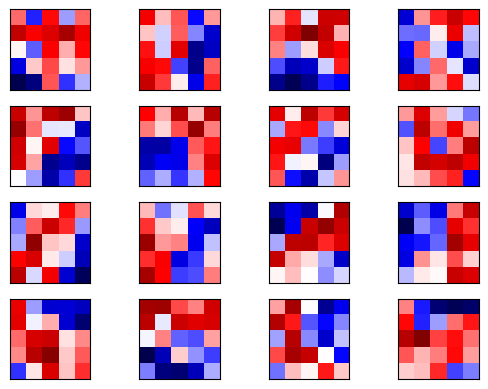

--- 绘制卷积层 2 的权重矩阵 ---


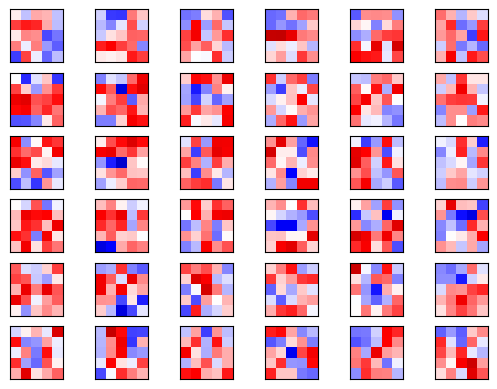

In [78]:
# 获取卷积层 1 的权重
# get_weights() 返回一个列表，其中第一个元素 [0] 是权重矩阵 (W)，第二个元素 [1] 是偏置向量 (b)
weights_conv1 = layer_conv1.get_weights()[0]

print("--- 绘制卷积层 1 的权重矩阵 ---")
# 绘制卷积层 1 的权重，我们只关注输入通道 0
plot_conv_weights(weights=weights_conv1, input_channel=0)

# 获取卷积层 2 的权重
weights_conv2 = layer_conv2.get_weights()[0]

print("--- 绘制卷积层 2 的权重矩阵 ---")
# 绘制卷积层 2 的权重，我们只关注输入通道 0
plot_conv_weights(weights=weights_conv2, input_channel=0)

In [79]:
def plot_conv_output(values):
    """
    绘制卷积层的输出特征图。
    
    参数:
    values: 卷积层的输出 (4维张量：[samples, height, width, filters])。
    """
    # 卷积层中的卷积核数量 (即输出通道数)
    # values 形状是 [1, height, width, filters]
    num_filters = values.shape[3]
    
    # 要绘制的网格数
    # 卷积核数量的平方根并向上取整。
    num_grids = math.ceil(math.sqrt(num_filters))
    
    # 创建带有网格子图的图像
    fig, axes = plt.subplots(num_grids, num_grids)
    
    # 自动调整子图参数
    fig.subplots_adjust(hspace=0.3, wspace=0.3)
    
    # 画出所有卷积核的输出图像
    for i, ax in enumerate(axes.flat):
        # 仅画出有效卷积核图像
        if i < num_filters:
            # 获取第 i 个卷积核的输出图像 (对于第0个样本)
            # values[0, :, :, i]
            img = values[0, :, :, i]
            
            # 画图.
            # interpolation='nearest' 保持像素块清晰，cmap='binary' 保持黑白灰度
            ax.imshow(img, interpolation='nearest', cmap='binary') 
            
        # 移除刻度线
        ax.set_xticks([])
        ax.set_yticks([]) 
        
    plt.show()

--- 绘制测试集的第一张原始图像 ---


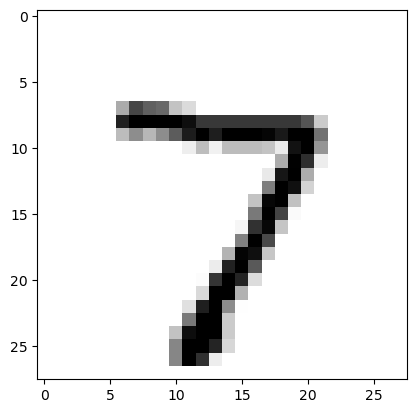

In [80]:
def plot_image(image):
    """
    绘制单个图像。
    
    参数:
    image: 要绘制的图像数组 (一维 784 元素，或二维 28x28)。
    """
    # 使用 img_shape (28, 28) 重塑图像并显示
    plt.imshow(image.reshape(img_shape),
               interpolation='nearest',
               cmap='binary')
    plt.show()

# ---------------------------------------------
# 绘制测试集的第一张图片
# ---------------------------------------------

# 获取测试集的第一张图片
# 注意：我们使用原始的 x_test[0] (未归一化、未扁平化) 进行可视化
# 如果您使用扁平化的 x_test_flat[0] 则需要先进行去扁平化
image1 = x_test[0]

# 调用辅助函数绘制图像
print("--- 绘制测试集的第一张原始图像 ---")
plot_image(image1)

In [81]:
# 创建一个 Keras 函数，输入是模型的输入层，输出是卷积层 1 的输出
# layer_input 和 layer_conv1 已在 5.2 节中定义
output_conv1 = K.function(inputs=[layer_input.input],
                          outputs=[layer_conv1.output])

print("--- K 函数 output_conv1 创建成功 ---")

--- K 函数 output_conv1 创建成功 ---


In [83]:
# 注意：image1 是原始图像 (28, 28) 形状
# 1. 对 image1 进行预处理：归一化
image1_normalized = image1.astype('float32') / 255.0

# 2. 扁平化并显式添加批次维度。形状从 (784,) 变为 (1, 784)
# (1, img_size_flat) 表示 1 个样本，每个样本 784 个特征
image1_flat_batch = image1_normalized.reshape(1, img_size_flat)

# 3. 使用 K.function 转换的函数获取输出
# 注意：现在使用单层列表 [image1_flat_batch]
layer_output1 = output_conv1([image1_flat_batch])[0]

# 4. 输出查看 layer_output1 的形状
print("layer_output1 的形状:")
print(layer_output1.shape)

layer_output1 的形状:
(1, 28, 28, 16)


--- 绘制卷积层 1 的输出 (16个特征图) ---


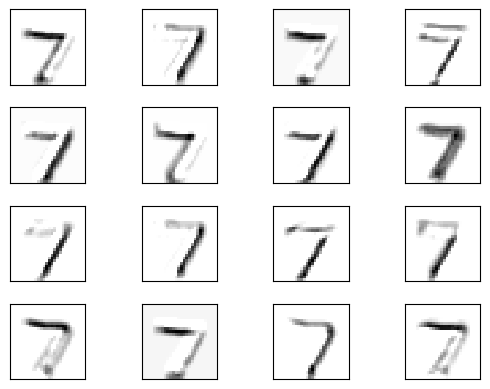

In [84]:
print("--- 绘制卷积层 1 的输出 (16个特征图) ---")

# 调用 plot_conv_output 函数绘制卷积层 1 的输出
# layer_output1 的形状是 (1, 28, 28, 16)
plot_conv_output(values=layer_output1)

In [86]:
# 使用 Functional Model API 创建一个新的模型 output_conv2
# 输入层 (layer_input.input) 保持不变
# 输出层设置为我们感兴趣的卷积层 2 的输出 (layer_conv2.output)
# layer_input 和 layer_conv2 已在 5.2 节中定义
output_conv2 = Model(inputs=layer_input.input,
                     outputs=layer_conv2.output)

print("--- Model 函数 output_conv2 创建成功 ---")

--- Model 函数 output_conv2 创建成功 ---


In [87]:
# 注意：
# image1_flat_batch 是之前创建的 (1, 784) 形状的 NumPy 数组，
# 已经过归一化和扁平化处理，并带有了批次维度。

print("--- 开始用 output_conv2 模型进行预测 ---")

# 调用 output_conv2 的 predict() 函数得到卷积层 2 的输出
# output_conv2.predict 期望输入形状为 (样本数, 784)
layer_output2 = output_conv2.predict(image1_flat_batch)

# 输出查看 layer_output2 的形状
print("\nlayer_output2 的形状:")
print(layer_output2.shape)

--- 开始用 output_conv2 模型进行预测 ---
1/1 [==============================] - 0s 94ms/step

layer_output2 的形状:
(1, 14, 14, 36)


--- 绘制卷积层 2 的输出 (36个特征图) ---


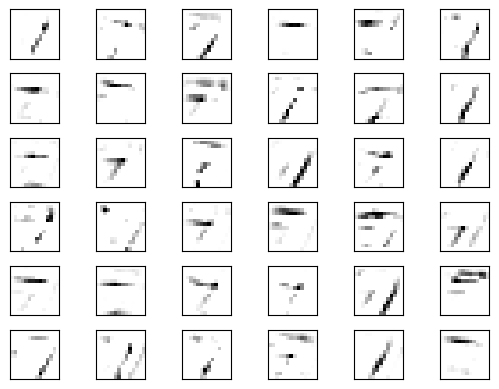

In [88]:
print("--- 绘制卷积层 2 的输出 (36个特征图) ---")

# 调用 plot_conv_output 函数绘制卷积层 2 的输出
# layer_output2 的形状是 (1, 14, 14, 36)
plot_conv_output(values=layer_output2)